# Рубежный контроль №1 

### Выполнил студент учебной группы РТ5-61Б Савельева В. О.
### Полученный вариант: 14
### Номер задачи: 2
Для заданного набора данных проведите обработку пропусков в данных для одного категориального и одного количественного признака. Какие способы обработки пропусков в данных для категориальных и количественных признаков Вы использовали? Какие признаки Вы будете использовать для дальнейшего построения моделей машинного обучения и почему?
### Полученный набор данных: 6
Admission Predict ver 1.1 https://www.kaggle.com/mohansacharya/graduate-admissions — прогнозирование поступления в аспирантуру

## 1. Импорт необходимых библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

plt.style.use('ggplot')
sns.set_palette('Set2')
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

print('Библиотеки успешно импортированы')

Библиотеки успешно импортированы


## 2. Загрузка данных и первичный анализ

In [2]:
# Загружаем датасет
df = pd.read_csv('Admission_Predict_Ver1.1.csv')

# Удаляем столбец Serial No. так как это не признак, а номер строки
df = df.drop('Serial No.', axis=1)

# Переименовываем столбцы
df.columns = [
    'GRE_Score', 'TOEFL_Score', 'University_Rating', 'SOP', 'LOR',
    'CGPA', 'Research', 'Chance_of_Admit'
]

# Преобразуем Research в категориальный с осмысленными метками
df['Research'] = df['Research'].map({0: 'Нет', 1: 'Есть'})

# Преобразуем University_Rating в категориальный
df['University_Rating'] = df['University_Rating'].astype('category')

# Информация о данных
print('Размер датасета:', df.shape)
print('\nПервые 10 строк:')
display(df.head(10))
print('\nОписательная статистика:')
display(df.describe(include='all'))

Размер датасета: (500, 8)

Первые 10 строк:


,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admit
0,337,118,4,4.500,4.500,9.650,Есть,0.920
1,324,107,4,4.000,4.500,8.870,Есть,0.760
2,316,104,3,3.000,3.500,8.000,Есть,0.720
3,322,110,3,3.500,2.500,8.670,Есть,0.800
4,314,103,2,2.000,3.000,8.210,Нет,0.650
5,330,115,5,4.500,3.000,9.340,Есть,0.900
6,321,109,3,3.000,4.000,8.200,Есть,0.750
7,308,101,2,3.000,4.000,7.900,Нет,0.680
8,302,102,1,2.000,1.500,8.000,Нет,0.500
9,323,108,3,3.500,3.000,8.600,Нет,0.450



Описательная статистика:


,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admit
count,500.000,500.000,500.000,500.000,500.000,500.000,500,500.000
unique,NaN,NaN,5.000,NaN,NaN,NaN,2,NaN
top,NaN,NaN,3.000,NaN,NaN,NaN,Есть,NaN
freq,NaN,NaN,162.000,NaN,NaN,NaN,280,NaN
mean,316.472,107.192,NaN,3.374,3.484,8.576,NaN,0.722
std,11.295,6.082,NaN,0.991,0.925,0.605,NaN,0.141
min,290.000,92.000,NaN,1.000,1.000,6.800,NaN,0.340
25%,308.000,103.000,NaN,2.500,3.000,8.128,NaN,0.630
50%,317.000,107.000,NaN,3.500,3.500,8.560,NaN,0.720
75%,325.000,112.000,NaN,4.000,4.000,9.040,NaN,0.820


In [3]:
# Наличие пропусков в исходных данных
print('Количество пропусков в каждом столбце:')
print(df.isnull().sum())
print(f'\nОбщее количество пропусков: {df.isnull().sum().sum()}')
print('\nТипы данных:')
print(df.dtypes)

Количество пропусков в каждом столбце:
GRE_Score            0
TOEFL_Score          0
University_Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance_of_Admit      0
dtype: int64

Общее количество пропусков: 0

Типы данных:
GRE_Score               int64
TOEFL_Score             int64
University_Rating    category
SOP                   float64
LOR                   float64
CGPA                  float64
Research                  str
Chance_of_Admit       float64
dtype: object


## 3. Создание дополнительного категориального признака

В датасете уже есть категориальные признаки (`University_Rating`, `Research`), но для выполнения задания создадим дополнительную категоризацию на основе количественного признака `CGPA`.

In [5]:
# Функция для категоризации CGPA
def categorize_cgpa(cgpa):
    if cgpa < 8.0:
        return 'Ниже среднего'
    elif cgpa < 9.0:
        return 'Средний'
    else:
        return 'Высокий'

# Применяем категоризацию
df['CGPA_Category'] = df['CGPA'].apply(categorize_cgpa)

print('Распределение категорий CGPA:')
print(df['CGPA_Category'].value_counts())
print(f'\nТип данных нового признака: {df["CGPA_Category"].dtype}')

Распределение категорий CGPA:
CGPA_Category
Средний          272
Высокий          144
Ниже среднего     84
Name: count, dtype: int64

Тип данных нового признака: str


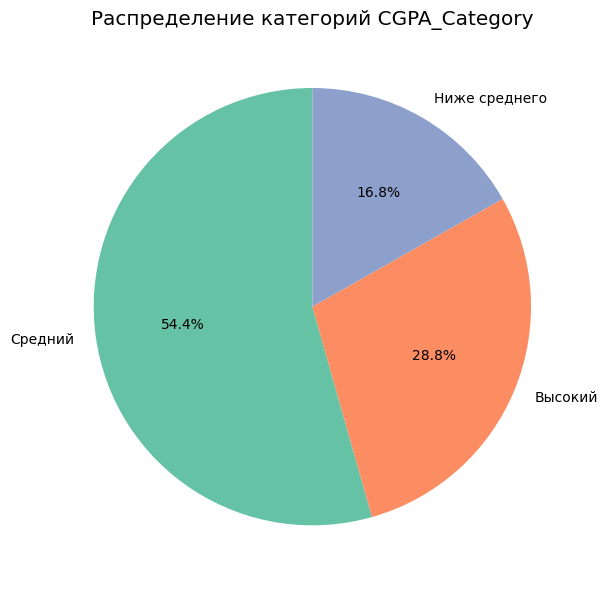

In [6]:
# Круговая диаграмма распределения категорий CGPA
fig, ax = plt.subplots(figsize=(8, 6))

category_counts = df['CGPA_Category'].value_counts()
ax.pie(category_counts.values, labels=category_counts.index, 
       autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2'))
ax.set_title('Распределение категорий CGPA_Category')

plt.tight_layout()
plt.show()

## 4. Искусственное создание пропусков

Заменим 20% случайных значений на NaN в одном количественном признаке (`GRE_Score`) и в одном категориальном признаке (`University_Rating`).

In [7]:
# Фиксируем random seed для воспроизводимости результатов
np.random.seed(42)

# Создаём копию DataFrame для работы с пропусками
df_missing = df.copy()

# Пропуски в количественном признаке (GRE_Score)
n_missing_num = int(0.2 * len(df_missing))  
missing_idx_num = np.random.choice(df_missing.index, n_missing_num, replace=False)
df_missing.loc[missing_idx_num, 'GRE_Score'] = np.nan

# Пропуски в категориальном признаке (University_Rating)
n_missing_cat = int(0.2 * len(df_missing))
missing_idx_cat = np.random.choice(df_missing.index, n_missing_cat, replace=False)
df_missing.loc[missing_idx_cat, 'University_Rating'] = np.nan

print('Количество пропусков после внесения:')
print(f'GRE_Score: {df_missing["GRE_Score"].isnull().sum()} '
      f'({df_missing["GRE_Score"].isnull().sum() / len(df_missing) * 100:.1f}%)')
print(f'University_Rating: {df_missing["University_Rating"].isnull().sum()} '
      f'({df_missing["University_Rating"].isnull().sum() / len(df_missing) * 100:.1f}%)')

Количество пропусков после внесения:
GRE_Score: 100 (20.0%)
University_Rating: 100 (20.0%)


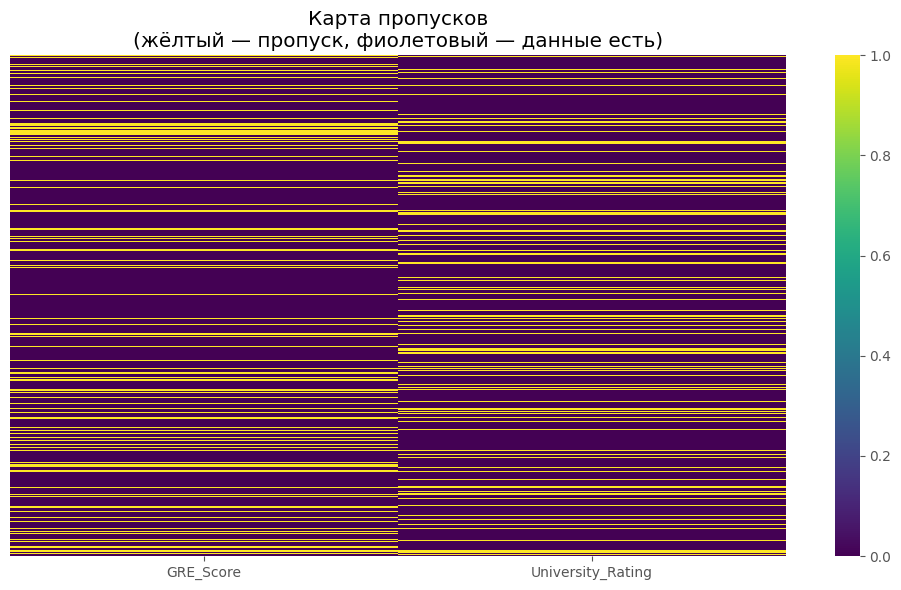

In [9]:
# Тепловая карта пропусков
fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(df_missing[['GRE_Score', 'University_Rating']].isnull(), 
            cbar=True, cmap='viridis', yticklabels=False, ax=ax)
ax.set_title('Карта пропусков\n(жёлтый — пропуск, фиолетовый — данные есть)')

plt.tight_layout()
plt.show()

In [10]:
print('Примеры строк с пропусками:')
display(df_missing[df_missing['GRE_Score'].isnull() | 
                  df_missing['University_Rating'].isnull()].head(10))

Примеры строк с пропусками:


,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admit,CGPA_Category
0,NaN,118,4,4.500,4.500,9.650,Есть,0.920,Высокий
1,324.000,107,NaN,4.000,4.500,8.870,Есть,0.760,Средний
2,NaN,104,3,3.000,3.500,8.000,Есть,0.720,Средний
9,NaN,108,3,3.500,3.000,8.600,Нет,0.450,Средний
11,NaN,111,4,4.000,4.500,9.000,Есть,0.840,Высокий
14,311.000,104,NaN,3.500,2.000,8.200,Есть,0.610,Средний
15,NaN,105,3,3.500,2.500,8.300,Нет,0.540,Средний
17,319.000,106,NaN,4.000,3.000,8.000,Есть,0.650,Средний
18,NaN,110,3,4.000,3.000,8.800,Нет,0.630,Средний
22,NaN,116,5,5.000,5.000,9.500,Есть,0.940,Высокий


## 5. Обработка пропусков в количественном признаке

Рассмотрим два метода заполнения пропусков для количественного признака `GRE_Score`:
- **Замена средним значением (mean imputation)**
- **Замена медианой (median imputation)**

In [11]:
# Оригинальная статистика до внесения пропусков
original_mean = df['GRE_Score'].mean()
original_median = df['GRE_Score'].median()
original_std = df['GRE_Score'].std()

# Статистика с пропусками
missing_mean = df_missing['GRE_Score'].mean()
missing_median = df_missing['GRE_Score'].median()

print('Сравнение статистик')
print(f'{"":20} {"Оригинал":>12} {"С пропусками":>15}')
print(f'{"Среднее":20} {original_mean:12.4f} {missing_mean:15.4f}')
print(f'{"Медиана":20} {original_median:12.4f} {missing_median:15.4f}')
print(f'{"Стд. откл.":20} {original_std:12.4f} {df_missing["GRE_Score"].std():15.4f}')

Сравнение статистик
                         Оригинал    С пропусками
Среднее                  316.4720        316.7275
Медиана                  317.0000        317.0000
Стд. откл.                11.2951         10.9692


In [12]:
# Метод 1: Замена средним значением
df_mean_imputed = df_missing.copy()
imputer_mean = SimpleImputer(strategy='mean')
df_mean_imputed['GRE_Score'] = imputer_mean.fit_transform(
    df_mean_imputed[['GRE_Score']]
)

# Метод 2: Замена медианой
df_median_imputed = df_missing.copy()
imputer_median = SimpleImputer(strategy='median')
df_median_imputed['GRE_Score'] = imputer_median.fit_transform(
    df_median_imputed[['GRE_Score']]
)

# Сравнение результатов
print('Сравнение методов заполнения (GRE_Score)')
print(f'{"":25} {"Оригинал":>10} {"Mean":>12} {"Median":>12}')
print(f'{"Среднее":25} {df["GRE_Score"].mean():10.4f} '
      f'{df_mean_imputed["GRE_Score"].mean():12.4f} '
      f'{df_median_imputed["GRE_Score"].mean():12.4f}')
print(f'{"Медиана":25} {df["GRE_Score"].median():10.4f} '
      f'{df_mean_imputed["GRE_Score"].median():12.4f} '
      f'{df_median_imputed["GRE_Score"].median():12.4f}')
print(f'{"Стд. откл.":25} {df["GRE_Score"].std():10.4f} '
      f'{df_mean_imputed["GRE_Score"].std():12.4f} '
      f'{df_median_imputed["GRE_Score"].std():12.4f}')

Сравнение методов заполнения (GRE_Score)
                            Оригинал         Mean       Median
Среднее                     316.4720     316.7275     316.7820
Медиана                     317.0000     316.7275     317.0000
Стд. откл.                   11.2951       9.8087       9.8093


**Вывод по количественному признаку:**  Замена медианой лучше работает при наличии выбросов — она меньше смещает медиану и стандартное отклонение. В дальнейшем будем использовать заполнение медианой как более устойчивый метод.

## 6. Обработка пропусков в категориальном признаке

Для категориального признака `University_Rating` используем метод **замены модой** (самым частым значением).

In [13]:
# Распределение категорий
print('Распределение рейтингов университетов (оригинал):')
print(df['University_Rating'].value_counts())
print(f'\nМода (самое частое значение): {df["University_Rating"].mode()[0]}')
print(f'Количество пропусков: {df_missing["University_Rating"].isnull().sum()}')

Распределение рейтингов университетов (оригинал):
University_Rating
3    162
2    126
4    105
5     73
1     34
Name: count, dtype: int64

Мода (самое частое значение): 3
Количество пропусков: 100


In [15]:
# Заполняем пропуски модой
# Берём версию с median imputation для количественного признака
df_filled = df_median_imputed.copy()

imputer_cat = SimpleImputer(strategy='most_frequent')
df_filled['University_Rating'] = imputer_cat.fit_transform(
    df_filled[['University_Rating']]
).ravel()  

print(f'GRE_Score: {df_filled["GRE_Score"].isnull().sum()} пропусков')
print(f'University_Rating: {df_filled["University_Rating"].isnull().sum()} пропусков')
print(f'\nОбщее количество пропусков: {df_filled.isnull().sum().sum()}')

GRE_Score: 0 пропусков
University_Rating: 0 пропусков

Общее количество пропусков: 0


**Вывод по категориальному признаку:** замена модой — логичный метод для категориальных данных. Категория «3» (рейтинг университета) встречается чаще всего и используется для заполнения пропусков. Распределение долей после заполнения изменилось незначительно.

## 7. Финальная проверка обработанных данных

In [17]:
print(f'\nРазмер данных: {df_filled.shape}')
print(f'Общее количество пропусков: {df_filled.isnull().sum().sum()}')
print('\nИнформация о данных:')
df_filled.info()
print('\nПервые 10 строк обработанных данных:')
display(df_filled.head(10))


Размер данных: (500, 9)
Общее количество пропусков: 0

Информация о данных:
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE_Score          500 non-null    float64
 1   TOEFL_Score        500 non-null    int64  
 2   University_Rating  500 non-null    float64
 3   SOP                500 non-null    float64
 4   LOR                500 non-null    float64
 5   CGPA               500 non-null    float64
 6   Research           500 non-null    str    
 7   Chance_of_Admit    500 non-null    float64
 8   CGPA_Category      500 non-null    str    
dtypes: float64(6), int64(1), str(2)
memory usage: 35.3 KB

Первые 10 строк обработанных данных:


,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admit,CGPA_Category
0,317.000,118,4.000,4.500,4.500,9.650,Есть,0.920,Высокий
1,324.000,107,3.000,4.000,4.500,8.870,Есть,0.760,Средний
2,317.000,104,3.000,3.000,3.500,8.000,Есть,0.720,Средний
3,322.000,110,3.000,3.500,2.500,8.670,Есть,0.800,Средний
4,314.000,103,2.000,2.000,3.000,8.210,Нет,0.650,Средний
5,330.000,115,5.000,4.500,3.000,9.340,Есть,0.900,Высокий
6,321.000,109,3.000,3.000,4.000,8.200,Есть,0.750,Средний
7,308.000,101,2.000,3.000,4.000,7.900,Нет,0.680,Ниже среднего
8,302.000,102,1.000,2.000,1.500,8.000,Нет,0.500,Средний
9,317.000,108,3.000,3.500,3.000,8.600,Нет,0.450,Средний


## 8. Построение Jointplot

Jointplot — график, объединяющий диаграмму рассеяния с гистограммами распределений каждой переменной по краям. Построим его для пары признаков: `GRE_Score` и `TOEFL_Score`.

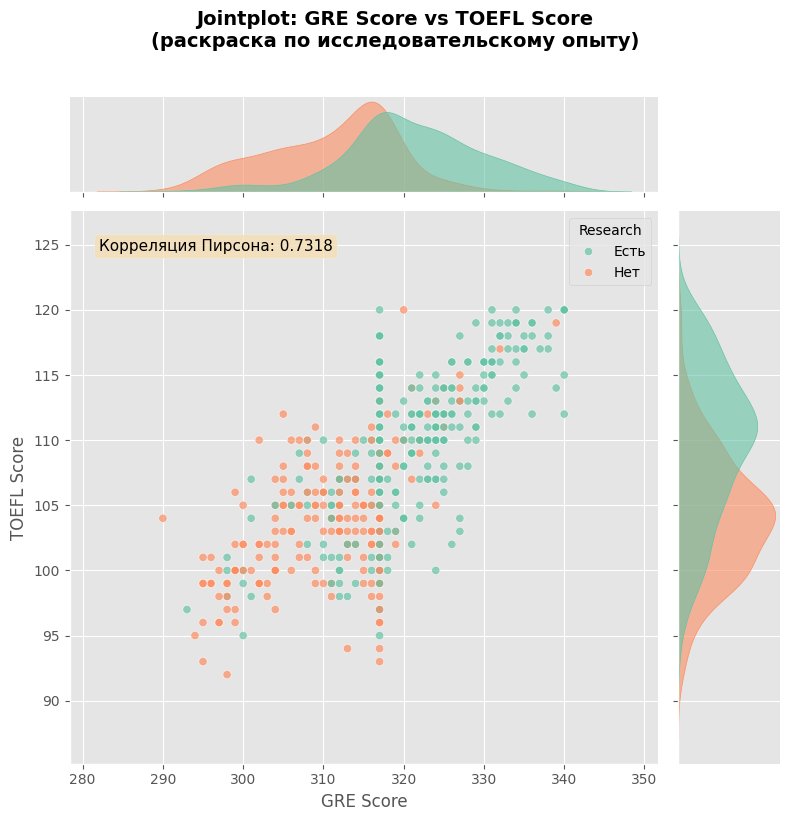

In [18]:
g = sns.jointplot(
    data=df_filled,
    x='GRE_Score',
    y='TOEFL_Score',
    hue='Research',          
    kind='scatter',          
    height=8,                
    alpha=0.7,               
    marginal_kws=dict(fill=True, alpha=0.6, common_norm=False)
)

# Настройка подписей
g.set_axis_labels('GRE Score', 'TOEFL Score', fontsize=12)
g.fig.suptitle('Jointplot: GRE Score vs TOEFL Score\n(раскраска по исследовательскому опыту)', 
               y=1.02, fontsize=14, fontweight='bold')

# Добавляем коэффициент корреляции
corr = df_filled['GRE_Score'].corr(df_filled['TOEFL_Score'])
g.ax_joint.text(0.05, 0.95, f'Корреляция Пирсона: {corr:.4f}', 
                transform=g.ax_joint.transAxes, fontsize=11,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

## 9. Ответы на контрольные вопросы

### Вопрос 1: Какие способы обработки пропусков в данных для категориальных и количественных признаков Вы использовали?

**Для количественного признака (`GRE_Score`):**
1. **Замена средним значением (mean imputation)** — простой метод, заменяет все пропуски на среднее арифметическое. Хорошо работает при нормальном распределении, но может искажать дисперсию.
2. **Замена медианой (median imputation)** — более устойчив к выбросам, рекомендуется при асимметричном распределении или наличии экстремальных значений. Сохраняет медиану выборки.

**Для категориального признака (`University_Rating`):**
1. **Замена модой (most frequent / mode imputation)** —  Пропуски заменяются категорией, которая встречается чаще всего (в нашем случае — рейтинг «3»). Метод сохраняет распределение категорий с минимальными искажениями.

---

### Вопрос 2: Какие признаки Вы будете использовать для дальнейшего построения моделей машинного обучения и почему?

Для построения моделей я буду использовать следующие признаки:
- `GRE_Score` — результат GRE (количественный)
- `TOEFL_Score` — результат TOEFL (количественный)
- `University_Rating` — рейтинг университета (категориальный, ordinal)
- `SOP` — сила мотивационного письма (количественный)
- `LOR` — сила рекомендательных писем (количественный)
- `CGPA` — средний балл (количественный)
- `Research` — наличие исследовательского опыта (категориальный, бинарный)

**Обоснование:**
1. **Все признаки имеют отношение к поступлению.** GRE, TOEFL и CGPA отражают академическую успеваемость, SOP и LOR — качество заявки, Research — практический опыт.
2. **Разнообразие типов данных** позволяет моделям улавливать разные аспекты: числовые показатели успеваемости и категориальные показатели опыта.

**Признак `CGPA_Category` не используется**, так как он искусственно создан из CGPA путём дискретизации и содержит ту же информацию с потерями — его использование привело бы к мультиколлинеарности и ухудшению качества модели.